In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [2]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/consumption/24pasos_mlp_consumption.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2017-11-24 23:40:00,-0.616186,-0.956513
2017-11-24 23:50:00,-0.689976,-1.030545
2017-11-25 00:00:00,-0.791756,-1.086928
2017-11-25 00:10:00,-0.867242,-1.109334
2017-11-25 00:20:00,-0.961389,-1.118081


In [3]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/consumption/24pasos_lstm_consumption.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2017-11-24 23:40:00,-0.616186,-0.965231
2017-11-24 23:50:00,-0.689976,-1.044010
2017-11-25 00:00:00,-0.791756,-1.097821
2017-11-25 00:10:00,-0.867242,-1.144845
2017-11-25 00:20:00,-0.961389,-1.183374


In [4]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/consumption/24pasos_gru_consumption.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2017-11-24 23:40:00,-0.616186,-0.970730
2017-11-24 23:50:00,-0.689976,-1.030196
2017-11-25 00:00:00,-0.791756,-1.079912
2017-11-25 00:10:00,-0.867242,-1.090756
2017-11-25 00:20:00,-0.961389,-1.106768


In [5]:
datosCross= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/consumption/crossformerConsumption.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2017-11-25 01:30:00,-1.353240,-1.270602
2017-11-25 01:40:00,-1.345607,-1.298394
2017-11-25 01:50:00,-1.349847,-1.326305
2017-11-25 02:00:00,-1.400737,-1.352366
2017-11-25 02:10:00,-1.449083,-1.379984


In [6]:
datosI= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/consumption/itransformerConsumption.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)

datosI.head()

,Originales,Predichos
date,,
2017-11-25 01:30:00,-1.353240,-1.290887
2017-11-25 01:40:00,-1.345607,-1.330180
2017-11-25 01:50:00,-1.349847,-1.328700
2017-11-25 02:00:00,-1.400737,-1.337106
2017-11-25 02:10:00,-1.449083,-1.332529


In [7]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARMAX/24paso/consumption/tftConsumption.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2017-11-24 02:40:00,-1.447386,-1.143083
2017-11-24 02:50:00,-1.495731,-1.145847
2017-11-24 03:00:00,-1.527962,-1.149245
2017-11-24 03:10:00,-1.505909,-1.151623
2017-11-24 03:20:00,-1.527962,-1.152836


In [8]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])



In [9]:
final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer')
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2017-11-24 02:40:00,NaN,NaN,NaN,NaN,NaN,-0.304303
2017-11-24 02:50:00,NaN,NaN,NaN,NaN,NaN,-0.349884
2017-11-24 03:00:00,NaN,NaN,NaN,NaN,NaN,-0.378717
2017-11-24 03:10:00,NaN,NaN,NaN,NaN,NaN,-0.354286
2017-11-24 03:20:00,NaN,NaN,NaN,NaN,NaN,-0.375126


In [10]:
final = final.dropna()
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2017-11-25 01:30:00,-0.156574,-0.070683,-0.016939,-0.082638,-0.062353,-0.269710
2017-11-25 01:40:00,-0.129127,-0.054824,0.026134,-0.047213,-0.015427,-0.253998
2017-11-25 01:50:00,-0.116831,-0.049010,0.038141,-0.023543,-0.021148,-0.248524
2017-11-25 02:00:00,-0.152495,-0.093377,0.013354,-0.048371,-0.063631,-0.289933
2017-11-25 02:10:00,-0.188480,-0.133646,-0.029454,-0.069099,-0.116553,-0.331666


Muestra aleatoria

In [11]:
final = final.sample(frac=0.10, random_state=42)

In [12]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [13]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print(p)


4.2529591801080156e-42


In [14]:
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print(p)


4.075446973145477e-43


In [15]:
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print(p)


2.365567352102343e-50


In [16]:
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print(p)


6.799094474878437e-51


In [17]:
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print(p)


3.391747353315466e-32


In [18]:
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print(p)


1.2670970873606498e-27


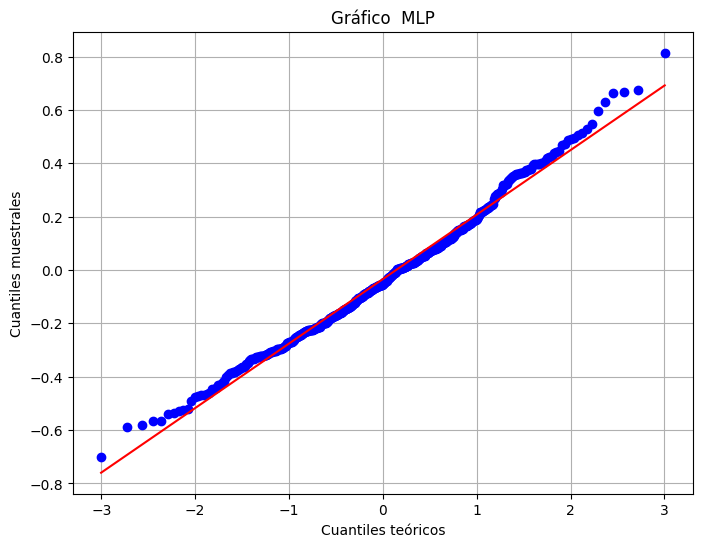

In [19]:
plt.figure(figsize=(8, 6))

stats.probplot(final["MLP"], dist="norm", plot=plt)
plt.title('Gráfico  MLP')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

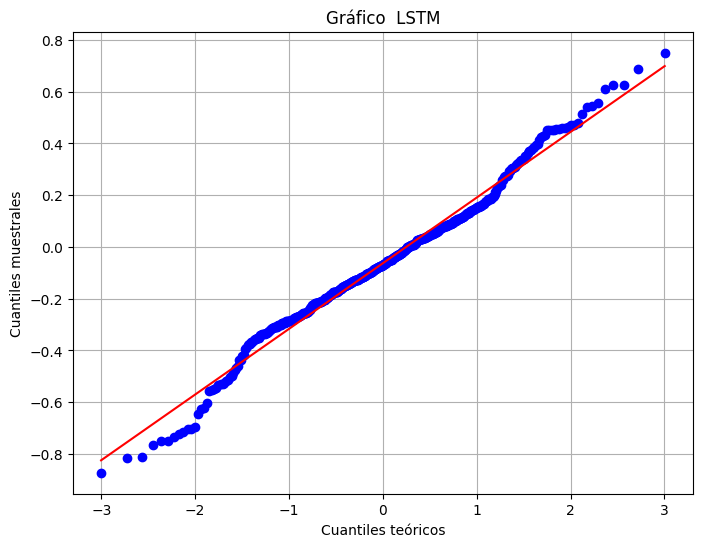

In [20]:
plt.figure(figsize=(8, 6))

stats.probplot(final["LSTM"], dist="norm", plot=plt)
plt.title('Gráfico  LSTM')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

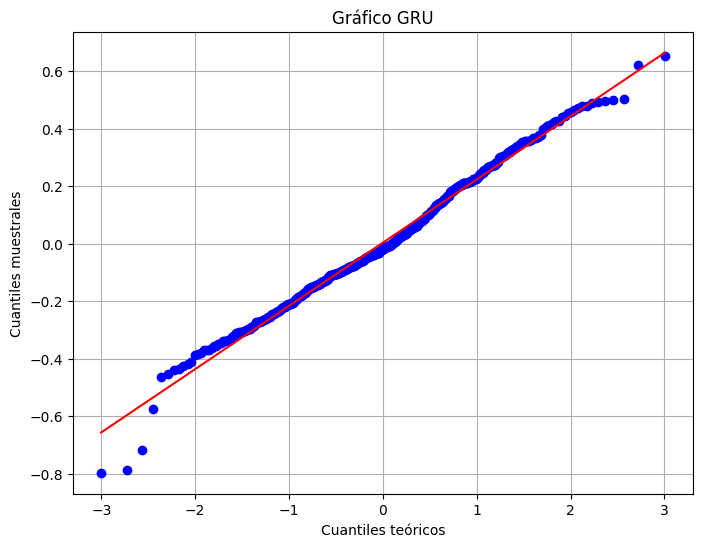

In [21]:
plt.figure(figsize=(8, 6))

stats.probplot(final["GRU"], dist="norm", plot=plt)
plt.title('Gráfico GRU')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

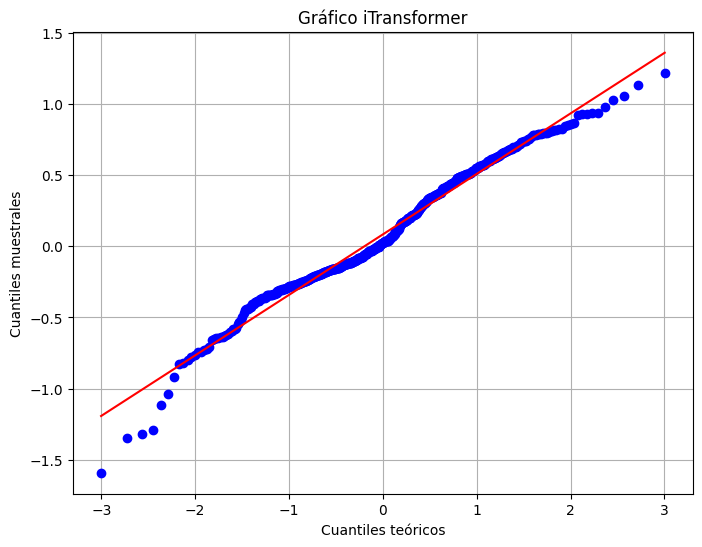

In [22]:
plt.figure(figsize=(8, 6))

stats.probplot(final["iTransformer"], dist="norm", plot=plt)
plt.title('Gráfico iTransformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

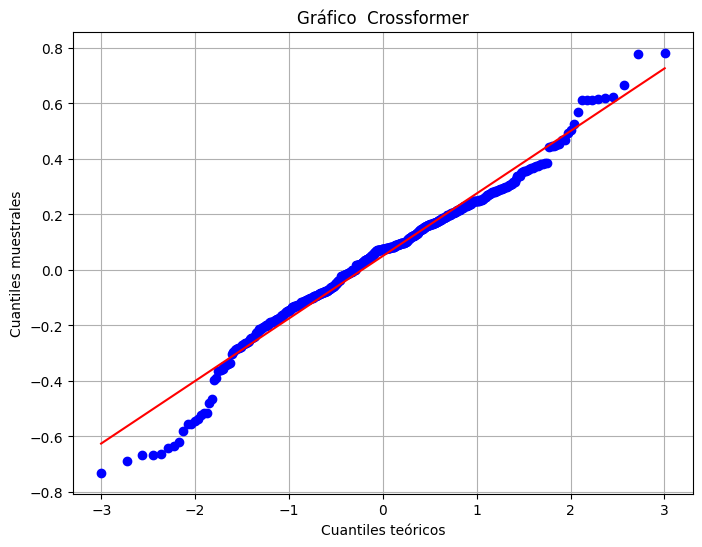

In [23]:
plt.figure(figsize=(8, 6))

stats.probplot(final["Crossformer"], dist="norm", plot=plt)
plt.title('Gráfico  Crossformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

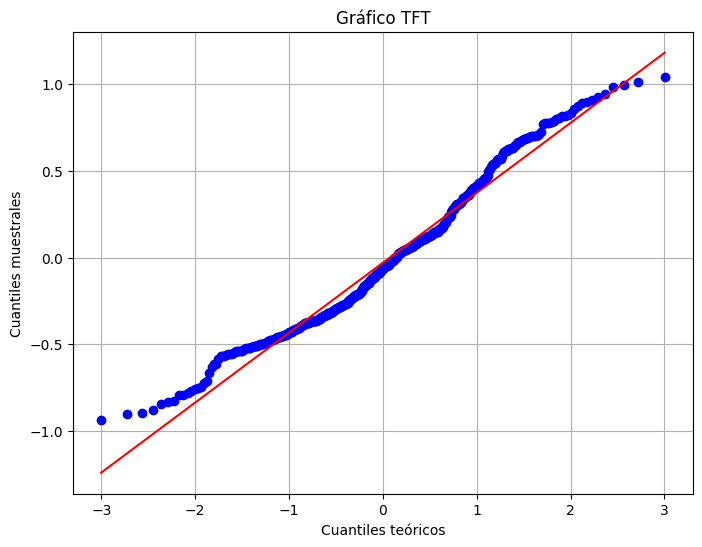

In [24]:
plt.figure(figsize=(8, 6))

stats.probplot(final["TFT"], dist="norm", plot=plt)
plt.title('Gráfico TFT')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

In [25]:
stat, p_value = stats.friedmanchisquare(final["MLP"], final["LSTM"], final["GRU"], final["Crossformer"], final["iTransformer"], final["TFT"])
print(p_value)

5.092731016508706e-54


In [26]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'LSTM'),
    ('MLP', 'GRU'),
    ('MLP', 'Crossformer'),
    ('MLP', 'iTransformer'),
    ('MLP', 'TFT'),
    ('LSTM', 'GRU'),
    ('LSTM', 'Crossformer'),
    ('LSTM', 'iTransformer'),
    ('LSTM', 'TFT'),
    ('GRU', 'Crossformer'),
    ('GRU', 'iTransformer'),
    ('GRU', 'TFT'),
    ('Crossformer', 'iTransformer'),
    ('Crossformer', 'TFT'),
    ('iTransformer', 'TFT')
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final[model1], final[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs LSTM,0.01012,0.15174,0.04046
1,MLP vs GRU,0.00000,0.00002,0.00001
2,MLP vs Crossformer,0.00000,0.00000,0.00000
3,MLP vs iTransformer,0.00000,0.00000,0.00000
4,MLP vs TFT,0.12537,1.00000,0.37612
5,LSTM vs GRU,0.00000,0.00000,0.00000
6,LSTM vs Crossformer,0.00000,0.00000,0.00000
7,LSTM vs iTransformer,0.00000,0.00000,0.00000
8,LSTM vs TFT,0.36936,1.00000,0.73872
9,GRU vs Crossformer,0.00000,0.00000,0.00000
